# Investment Readiness Screener — Phase 3: Screening & Analysis

**Crystal Olisa · Operations Generalist**

This notebook is Phase 3 of a three-phase investment pipeline:

| Phase | Script | What it does |
|---|---|---|
| 1 — Ingestion | `generate_profiles.py` | Generates 100 structured company submission forms as JSON |
| 2 — Extraction | `extract_and_validate.py` | Runs four-gate validation, derives metrics, outputs master CSV |
| 3 — Screening | This notebook | Applies investment thresholds, produces flags and charts |

**Data source:** World Bank Enterprise Surveys — indicator-level data for Nigeria, Kenya, Ghana, South Africa, and Ethiopia (2006–2025). Revenue growth distributions and finance constraint rates calibrated from publicly available WBES indicators (enterprisesurveys.org). Synthetic company profiles generated to reflect realistic African mid-market SME pipeline variance.

**Role context:** As a Digital Engagement Analyst supporting private equity DealRooms for African SMEs, I reviewed submitted company financials to determine whether a business cleared the bar for an investment conversation. This pipeline automates that first-pass screen.

---

### Screening thresholds

| Signal | Advance | Review | Decline |
|---|---|---|---|
| Revenue (USD) | > $1.5M | > $1.0M | ≤ $1.0M |
| EBITDA margin | ≥ 15% | ≥ 5% | < 5% |
| Revenue growth (YoY) | ≥ 10% | ≥ 3% | < 3% |
| Debt-to-equity | ≤ 2.0 | ≤ 3.0 | > 3.0 |

**Decision logic:** 4 signals at Advance threshold → **Advance**. 2–3 signals at Review or better → **Review**. Fewer than 2 → **Decline**. Insufficient data to assess → **Insufficient Data**.

---

## Section 0 — Setup and load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

os.makedirs('../charts', exist_ok=True)

df = pd.read_csv('../data/screening_results.csv')

print(f'Total companies in pipeline: {len(df)}')
print()
print('Pipeline status on arrival at Phase 3:')
print(df['pipeline_status'].value_counts())
print()

df_screen     = df[df['pipeline_status'].isin(['Validated','Partial'])].copy()
df_deferred   = df[df['pipeline_status'] == 'Deferred'].copy()
df_incomplete = df[df['pipeline_status'] == 'Incomplete'].copy()

print(f'Screenable companies: {len(df_screen)}')
print()
print('Signal availability in screenable pool:')
for col in ['revenue_usd_millions','ebitda_margin_pct','revenue_growth_pct','debt_to_equity']:
    n = df_screen[col].notna().sum()
    print(f'  {col}: {n}/{len(df_screen)}')

Total companies in pipeline: 100

Pipeline status on arrival at Phase 3:
pipeline_status
Validated    46
Partial      37
Deferred     17
Name: count, dtype: int64

Screenable companies: 83

Signal availability in screenable pool:
  revenue_usd_millions: 83/83
  ebitda_margin_pct: 61/83
  revenue_growth_pct: 74/83
  debt_to_equity: 63/83


## Section 1 — Apply screening thresholds

**What we're doing:** Scoring each signal for each screenable company and assigning an investment flag.

**Why it matters:** A company with a missing signal gets scored only on the signals available. If fewer than 2 signals can be assessed, the company is flagged Insufficient Data rather than Decline — the distinction matters operationally. A Decline is a decision. Insufficient Data is a data quality problem that requires a different follow-up action.

In [2]:
REV_ADVANCE,    REV_REVIEW    = 1.5,  1.0
EBITDA_ADVANCE, EBITDA_REVIEW = 15.0, 5.0
GROWTH_ADVANCE, GROWTH_REVIEW = 10.0, 3.0
D2E_ADVANCE,    D2E_REVIEW    = 2.0,  3.0

def score_signal(value, advance_t, review_t, higher_is_better=True):
    if pd.isna(value): return None
    if higher_is_better:
        if value >= advance_t: return 'advance'
        if value >= review_t:  return 'review'
        return 'decline'
    else:
        if value <= advance_t: return 'advance'
        if value <= review_t:  return 'review'
        return 'decline'

def assign_flag(row):
    scores = [
        score_signal(row['revenue_usd_millions'], REV_ADVANCE,    REV_REVIEW),
        score_signal(row['ebitda_margin_pct'],    EBITDA_ADVANCE,  EBITDA_REVIEW),
        score_signal(row['revenue_growth_pct'],   GROWTH_ADVANCE,  GROWTH_REVIEW),
        score_signal(row['debt_to_equity'],       D2E_ADVANCE,     D2E_REVIEW, higher_is_better=False),
    ]
    available    = [s for s in scores if s is not None]
    if len(available) < 2: return 'Insufficient Data'
    advance_count = available.count('advance')
    non_decline   = sum(1 for s in available if s in ('advance','review'))
    if len(available) == 4 and advance_count == 4: return 'Advance'
    if non_decline >= 2: return 'Review'
    return 'Decline'

df_screen['rev_score']    = df_screen['revenue_usd_millions'].apply(lambda x: score_signal(x, REV_ADVANCE, REV_REVIEW))
df_screen['ebitda_score'] = df_screen['ebitda_margin_pct'].apply(lambda x: score_signal(x, EBITDA_ADVANCE, EBITDA_REVIEW))
df_screen['growth_score'] = df_screen['revenue_growth_pct'].apply(lambda x: score_signal(x, GROWTH_ADVANCE, GROWTH_REVIEW))
df_screen['d2e_score']    = df_screen['debt_to_equity'].apply(lambda x: score_signal(x, D2E_ADVANCE, D2E_REVIEW, higher_is_better=False))
df_screen['signals_assessed'] = df_screen[['rev_score','ebitda_score','growth_score','d2e_score']].notna().sum(axis=1)
df_screen['investment_flag']  = df_screen.apply(assign_flag, axis=1)

print('Investment flag distribution (screenable companies):')
print(df_screen['investment_flag'].value_counts())
print()
advance_rate = len(df_screen[df_screen['investment_flag']=='Advance']) / len(df_screen) * 100
print(f'Advance rate: {advance_rate:.1f}% of screenable companies')

Investment flag distribution (screenable companies):
investment_flag
Review     43
Decline    29
Advance    11
Name: count, dtype: int64

Advance rate: 13.3% of screenable companies


## Section 2 — Chart 1: Pipeline conversion funnel

**What we're doing:** Showing how 100 submitted companies convert through each stage of the pipeline.

**Why it matters:** The funnel shows not just the final number but where attrition happens. Companies lost at Gate 0 are a different problem from companies lost at the screening stage — one is a sourcing calibration issue, the other is a submission quality issue.

**Saved to:** `../charts/chart_1_pipeline_funnel.png`

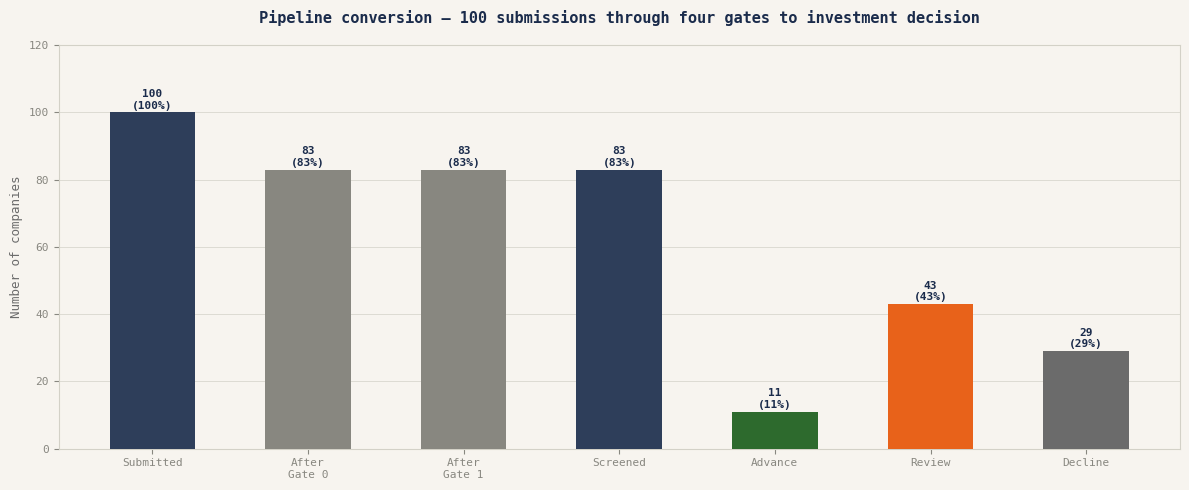

Saved: charts/chart_1_pipeline_funnel.png


In [3]:
matplotlib.rcParams['font.family'] = 'monospace'

n_total    = len(df)
n_deferred = len(df_deferred)
n_incompl  = len(df_incomplete)
n_screen   = len(df_screen)
n_advance  = len(df_screen[df_screen['investment_flag']=='Advance'])
n_review   = len(df_screen[df_screen['investment_flag']=='Review'])
n_decline  = len(df_screen[df_screen['investment_flag']=='Decline'])

stages = ['Submitted','After\nGate 0','After\nGate 1','Screened','Advance','Review','Decline']
values = [n_total, n_total-n_deferred, n_total-n_deferred-n_incompl, n_screen, n_advance, n_review, n_decline]
colors = ['#2E3E5A','#888780','#888780','#2E3E5A','#2D6A2D','#E8621A','#6B6B6B']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

bars = ax.bar(stages, values, color=colors, width=0.55, zorder=3)
for bar, val in zip(bars, values):
    pct = val / n_total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}\n({pct:.0f}%)', ha='center', va='bottom',
            fontsize=8, color='#1A2B4B', fontfamily='monospace', fontweight='bold')

ax.set_title('Pipeline conversion — 100 submissions through four gates to investment decision',
             fontsize=11, fontweight='bold', color='#1A2B4B', fontfamily='monospace', pad=16)
ax.set_ylabel('Number of companies', fontsize=9, color='#6B6B6B', fontfamily='monospace')
ax.tick_params(colors='#888780', labelsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('#D3D1C7')
ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, n_total * 1.2)

plt.tight_layout()
plt.savefig('../charts/chart_1_pipeline_funnel.png', dpi=150, bbox_inches='tight', facecolor='#F7F4EF')
plt.show()
print('Saved: charts/chart_1_pipeline_funnel.png')

## Section 3 — Chart 2: Signal failure breakdown

**What we're doing:** Showing which signals are failing most frequently across the screenable pool.

**Why it matters:** Signal failure rates are sourcing intelligence. The pattern determines the operational response — a debt-to-equity failure pattern calls for different sourcing adjustments than a revenue failure pattern.

**Saved to:** `../charts/chart_2_signal_failures.png`

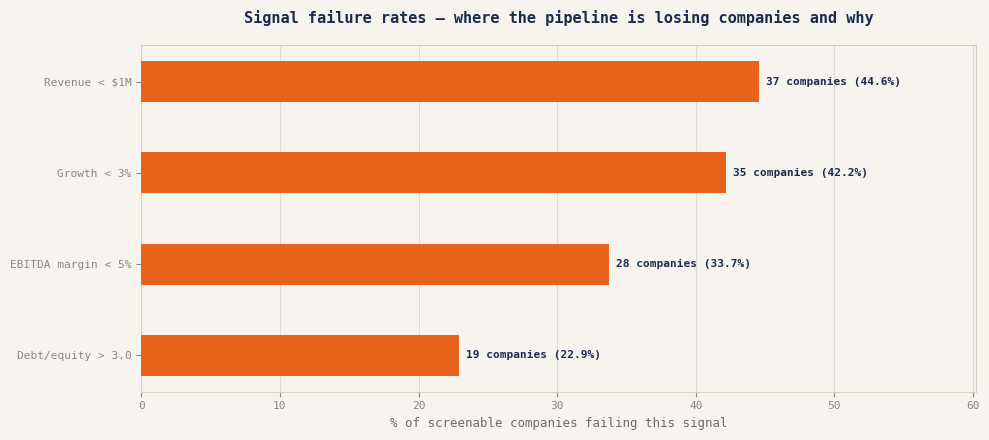

Saved: charts/chart_2_signal_failures.png


In [4]:
signal_map = {
    'Revenue < $1M':      df_screen['rev_score'].eq('decline').sum(),
    'EBITDA margin < 5%': df_screen[df_screen['ebitda_score'].notna()]['ebitda_score'].eq('decline').sum(),
    'Growth < 3%':        df_screen[df_screen['growth_score'].notna()]['growth_score'].eq('decline').sum(),
    'Debt/equity > 3.0':  df_screen[df_screen['d2e_score'].notna()]['d2e_score'].eq('decline').sum(),
}

pairs = sorted(zip(signal_map.values(), signal_map.keys()), reverse=True)
vals_s, labs_s = zip(*pairs)
pcts = [v / len(df_screen) * 100 for v in vals_s]

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

bars = ax.barh(labs_s, pcts, color='#E8621A', height=0.45, zorder=3)
for bar, val, pct in zip(bars, vals_s, pcts):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} companies ({pct:.1f}%)', ha='left', va='center',
            fontsize=8, color='#1A2B4B', fontfamily='monospace', fontweight='bold')

ax.set_title('Signal failure rates — where the pipeline is losing companies and why',
             fontsize=11, fontweight='bold', color='#1A2B4B', fontfamily='monospace', pad=16)
ax.set_xlabel('% of screenable companies failing this signal', fontsize=9, color='#6B6B6B', fontfamily='monospace')
ax.tick_params(colors='#888780', labelsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('#D3D1C7')
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.invert_yaxis()
ax.set_xlim(0, max(pcts) * 1.35)

plt.tight_layout()
plt.savefig('../charts/chart_2_signal_failures.png', dpi=150, bbox_inches='tight', facecolor='#F7F4EF')
plt.show()
print('Saved: charts/chart_2_signal_failures.png')

## Section 4 — Chart 3: EBITDA margin vs revenue (coloured by flag)

**What we're doing:** Plotting the two most analytically important signals against each other, coloured by investment flag.

**Why it matters:** Revenue and EBITDA margin together answer the core investability question — is this company big enough and efficient enough? The scatter shows the population shape and makes the decision logic visible through threshold lines.

**Saved to:** `../charts/chart_3_ebitda_vs_revenue.png`

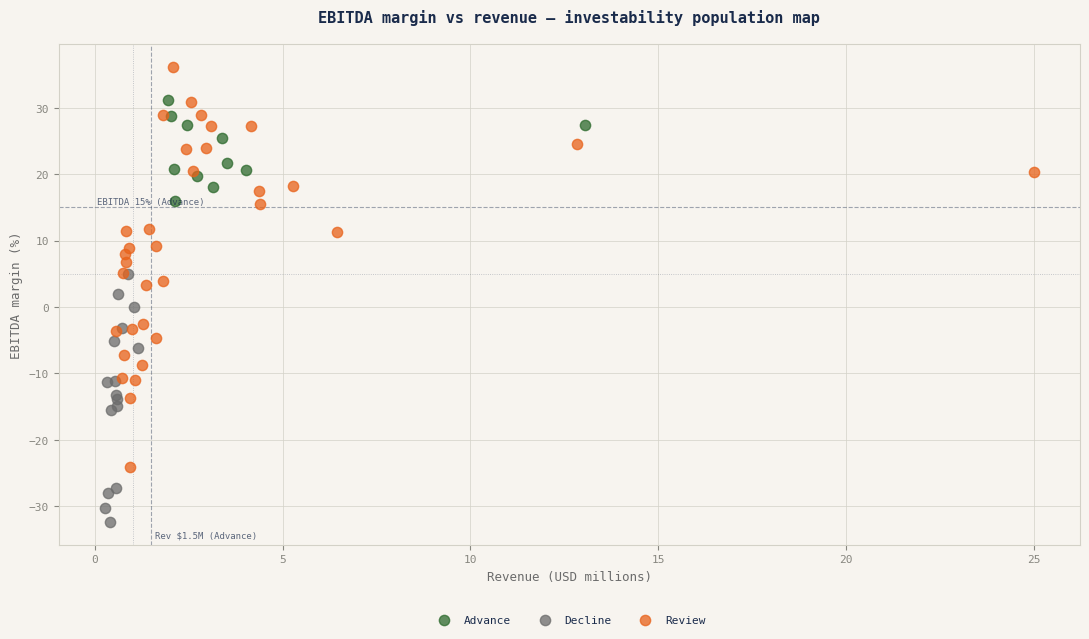

Saved: charts/chart_3_ebitda_vs_revenue.png


In [5]:
flag_colors = {
    'Advance':           '#2D6A2D',
    'Review':            '#E8621A',
    'Decline':           '#6B6B6B',
    'Insufficient Data': '#2E3E5A',
}

df_plot = df_screen[df_screen['ebitda_margin_pct'].notna()].copy()

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

for flag, group in df_plot.groupby('investment_flag'):
    ax.scatter(group['revenue_usd_millions'], group['ebitda_margin_pct'],
               c=flag_colors.get(flag, '#888780'), label=flag, alpha=0.75, s=55, zorder=3)

ax.axvline(x=REV_ADVANCE,    color='#1A2B4B', lw=0.8, ls='--', alpha=0.4)
ax.axvline(x=REV_REVIEW,     color='#1A2B4B', lw=0.6, ls=':',  alpha=0.3)
ax.axhline(y=EBITDA_ADVANCE, color='#1A2B4B', lw=0.8, ls='--', alpha=0.4)
ax.axhline(y=EBITDA_REVIEW,  color='#1A2B4B', lw=0.6, ls=':',  alpha=0.3)

ymin = ax.get_ylim()[0]
ax.text(REV_ADVANCE + 0.1, ymin + 1, 'Rev $1.5M (Advance)', fontsize=6.5,
        color='#1A2B4B', fontfamily='monospace', alpha=0.7)
ax.text(0.05, EBITDA_ADVANCE + 0.5, 'EBITDA 15% (Advance)', fontsize=6.5,
        color='#1A2B4B', fontfamily='monospace', alpha=0.7)

ax.set_title('EBITDA margin vs revenue — investability population map',
             fontsize=11, fontweight='bold', color='#1A2B4B', fontfamily='monospace', pad=16)
ax.set_xlabel('Revenue (USD millions)', fontsize=9, color='#6B6B6B', fontfamily='monospace')
ax.set_ylabel('EBITDA margin (%)', fontsize=9, color='#6B6B6B', fontfamily='monospace')
ax.tick_params(colors='#888780', labelsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('#D3D1C7')
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=8, framealpha=0, labelcolor='#1A2B4B',
          loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)

plt.tight_layout()
plt.savefig('../charts/chart_3_ebitda_vs_revenue.png', dpi=150, bbox_inches='tight', facecolor='#F7F4EF')
plt.show()
print('Saved: charts/chart_3_ebitda_vs_revenue.png')

## Section 5 — Chart 4: Pipeline health dashboard

**What we're doing:** A two-panel view showing pipeline status breakdown and data completeness distribution.

**Why it matters:** Pipeline health answers a different question from screening results. Screening tells you which companies are investable. Pipeline health tells you whether the intake process is functioning.

**Saved to:** `../charts/chart_4_pipeline_health.png`

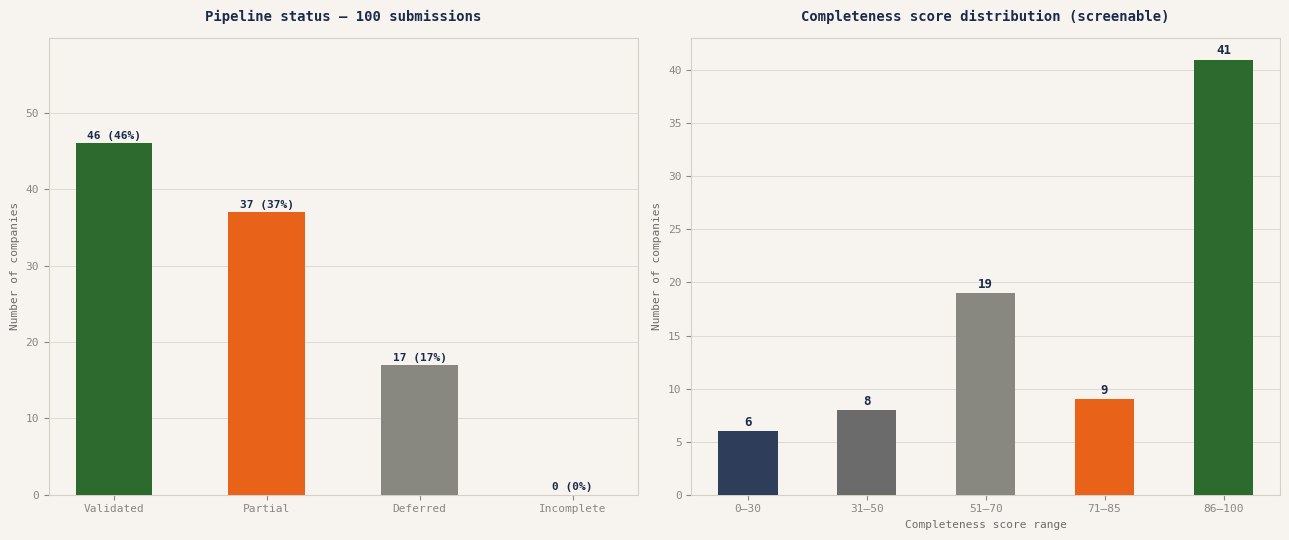

Saved: charts/chart_4_pipeline_health.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('#F7F4EF')

# Panel 1: Pipeline status
ax1.set_facecolor('#F7F4EF')
status_order  = ['Validated','Partial','Deferred','Incomplete']
status_colors = ['#2D6A2D','#E8621A','#888780','#2E3E5A']
sc = df['pipeline_status'].value_counts()
counts1 = [sc.get(s, 0) for s in status_order]

bars1 = ax1.bar(status_order, counts1, color=status_colors, width=0.5, zorder=3)
for bar, val in zip(bars1, counts1):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val} ({val/len(df)*100:.0f}%)', ha='center', va='bottom',
             fontsize=8, color='#1A2B4B', fontfamily='monospace', fontweight='bold')
ax1.set_title('Pipeline status — 100 submissions', fontsize=10, fontweight='bold',
              color='#1A2B4B', fontfamily='monospace', pad=12)
ax1.set_ylabel('Number of companies', fontsize=8, color='#6B6B6B', fontfamily='monospace')
ax1.tick_params(colors='#888780', labelsize=8)
for spine in ax1.spines.values(): spine.set_edgecolor('#D3D1C7')
ax1.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax1.set_axisbelow(True)
ax1.set_ylim(0, max(counts1) * 1.3)

# Panel 2: Completeness score distribution
ax2.set_facecolor('#F7F4EF')
completeness = df_screen['completeness_score'].dropna()
bins         = [0, 30, 50, 70, 85, 100]
bin_labels   = ['0–30','31–50','51–70','71–85','86–100']
bin_colors   = ['#2E3E5A','#6B6B6B','#888780','#E8621A','#2D6A2D']
counts2, _   = np.histogram(completeness, bins=bins)

bars2 = ax2.bar(bin_labels, counts2, color=bin_colors, width=0.5, zorder=3)
for bar, val in zip(bars2, counts2):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom',
                 fontsize=9, color='#1A2B4B', fontfamily='monospace', fontweight='bold')
ax2.set_title('Completeness score distribution (screenable)', fontsize=10, fontweight='bold',
              color='#1A2B4B', fontfamily='monospace', pad=12)
ax2.set_xlabel('Completeness score range', fontsize=8, color='#6B6B6B', fontfamily='monospace')
ax2.set_ylabel('Number of companies', fontsize=8, color='#6B6B6B', fontfamily='monospace')
ax2.tick_params(colors='#888780', labelsize=8)
for spine in ax2.spines.values(): spine.set_edgecolor('#D3D1C7')
ax2.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../charts/chart_4_pipeline_health.png', dpi=150, bbox_inches='tight', facecolor='#F7F4EF')
plt.show()
print('Saved: charts/chart_4_pipeline_health.png')

## Section 6 — Sector and country breakdown

In [7]:
print('Investment flags by sector (screenable companies):')
sector_bd = pd.crosstab(df_screen['sector'], df_screen['investment_flag'])
sector_bd['total'] = sector_bd.sum(axis=1)
if 'Advance' in sector_bd.columns:
    sector_bd['advance_rate_%'] = (sector_bd['Advance'] / sector_bd['total'] * 100).round(1)
print(sector_bd.to_string())
print()
print('Investment flags by country (screenable companies):')
country_bd = pd.crosstab(df_screen['country'], df_screen['investment_flag'])
country_bd['total'] = country_bd.sum(axis=1)
if 'Advance' in country_bd.columns:
    country_bd['advance_rate_%'] = (country_bd['Advance'] / country_bd['total'] * 100).round(1)
print(country_bd.to_string())

Investment flags by sector (screenable companies):
investment_flag  Advance  Decline  Review  total  advance_rate_%
sector                                                          
Agribusiness           2        4       6     12            16.7
Energy                 2        5       6     13            15.4
Fintech                0        2       8     10             0.0
Healthcare             1        7       6     14             7.1
Logistics              2        4       4     10            20.0
Manufacturing          2        4       4     10            20.0
Retail                 2        3       9     14            14.3

Investment flags by country (screenable companies):
investment_flag  Advance  Decline  Review  total  advance_rate_%
country                                                         
Egypt                  1        5       6     12             8.3
Ethiopia               0        4       7     11             0.0
Ghana                  1        5       4     10   

## Section 7 — Full results export

In [8]:
flag_cols = ['submission_id','investment_flag','rev_score','ebitda_score',
             'growth_score','d2e_score','signals_assessed']
df_final = df.merge(df_screen[flag_cols], on='submission_id', how='left')
df_final['investment_flag'] = df_final.apply(
    lambda r: r['pipeline_status'] if pd.isna(r['investment_flag']) else r['investment_flag'], axis=1)

df_final.to_csv('../data/investment_flags_final.csv', index=False)

print('FINAL RESULTS — ALL 100 COMPANIES')
print('=' * 60)
print(df_final['investment_flag'].value_counts().to_string())
print()
print('Advance companies:')
advance = df_final[df_final['investment_flag']=='Advance'][[
    'submission_id','company_name','country','sector',
    'revenue_usd_millions','ebitda_margin_pct','revenue_growth_pct','debt_to_equity'
]].sort_values('revenue_usd_millions', ascending=False)
print(advance.to_string(index=False))
print()
print('Saved: data/investment_flags_final.csv')

FINAL RESULTS — ALL 100 COMPANIES
investment_flag
Review      43
Decline     29
Deferred    17
Advance     11

Advance companies:
submission_id           company_name      country        sector  revenue_usd_millions  ebitda_margin_pct  revenue_growth_pct  debt_to_equity
        AF055     Waterberg Holdings       Rwanda  Agribusiness                13.059              27.44                11.5            1.05
        AF052      Thorn Tree Energy South Africa     Logistics                 4.010              20.61                13.7            1.56
        AF040    Flame Tree Ventures       Rwanda Manufacturing                 3.509              21.62                10.6            1.57
        AF026     River Basin Retail        Egypt        Retail                 3.391              25.39                19.7            1.56
        AF010 Horizon Healthcare Ltd      Nigeria     Logistics                 3.135              18.04                15.8            0.73
        AF036      Boma 

---

## Analytical decisions

| Decision | Rationale |
|---|---|
| Minimum 3 years operating history (Gate 0) | EBITDA from a single year is not a reliable signal — it could reflect a launch spike rather than sustainable margin |
| Completeness gate before screening (Gate 1) | Scoring a company on 1 signal produces a misleading flag. Insufficient Data is a different operational action from Decline |
| EBITDA reconciliation check (Gate 2) | Submitted EBITDA is cross-checked against derived (gross profit − opex). >5% variance flags for reviewer check before the number is used in a decision |
| Three-tier flag (Advance/Review/Decline) | Collapse to binary pass/fail loses borderline companies that warrant a conditional conversation |
| Require all 4 signals at Advance for Advance flag | Missing fields could mask a failing signal. Full visibility required for the highest confidence flag |

---

**World Bank Enterprise Survey calibration sources:**
- Real annual sales growth (%) — Nigeria, Kenya, Ghana, South Africa, Ethiopia, 2006–2025. `WB_ES_T_PERF1`
- % of firms identifying access to finance as a major constraint — same five countries. `WB_ES_T_FIN16`
- Source: Enterprise Surveys, World Bank Group. https://www.enterprisesurveys.org

*The pipeline does not replace the investment conversation. It makes the right conversations possible faster.*